# 13_feedforward

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyper-parameters 
input_size = 784 # 28x28
hidden_size = 500 
num_classes = 10
num_epochs = 2
batch_size = 100
learning_rate = 0.001

In [4]:
# MNIST dataset 
train_dataset = torchvision.datasets.MNIST(root='./data', 
                                           train=True, 
                                           transform=transforms.ToTensor(),  
                                           download=True)

test_dataset = torchvision.datasets.MNIST(root='./data', 
                                          train=False, 
                                          transform=transforms.ToTensor(),
                                          download=True)

# Data loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)

In [5]:
len(train_loader)

600

In [6]:
examples = iter(test_loader)
example_data, example_targets = next(examples)

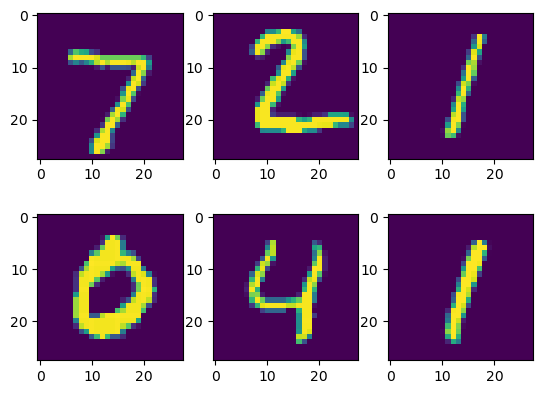

In [7]:
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(example_data[i][0]) #, cmap='viridis')
plt.show()

In [8]:
# Fully connected neural network with one hidden layer
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.input_size = input_size
        self.l1 = nn.Linear(input_size, hidden_size) 
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size, num_classes)  
    
    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        # no activation and no softmax at the end
        return out

In [9]:
model = NeuralNet(input_size, hidden_size, num_classes).to(device)

In [10]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) 

In [11]:
# Train the model
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):  
        # origin shape: [100, 1, 28, 28]
        # resized: [100, 784]
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i+1) % 100 == 0:
            print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

Epoch [1/2], Step [100/600], Loss: 0.2480
Epoch [1/2], Step [200/600], Loss: 0.3936
Epoch [1/2], Step [300/600], Loss: 0.2241
Epoch [1/2], Step [400/600], Loss: 0.2121
Epoch [1/2], Step [500/600], Loss: 0.2096
Epoch [1/2], Step [600/600], Loss: 0.1690
Epoch [2/2], Step [100/600], Loss: 0.1859
Epoch [2/2], Step [200/600], Loss: 0.0886
Epoch [2/2], Step [300/600], Loss: 0.0719
Epoch [2/2], Step [400/600], Loss: 0.1257
Epoch [2/2], Step [500/600], Loss: 0.2253
Epoch [2/2], Step [600/600], Loss: 0.0400


In [12]:
PATH = './digit_classifier.pth'
torch.save(model.state_dict(), PATH)

In [14]:
model = NeuralNet(input_size, hidden_size, num_classes).to(device)
model.load_state_dict(torch.load(PATH))
print(model.state_dict())

OrderedDict([('l1.weight', tensor([[ 0.0009,  0.0124, -0.0323,  ..., -0.0213,  0.0047, -0.0062],
        [-0.0060, -0.0075,  0.0144,  ..., -0.0008,  0.0217, -0.0105],
        [ 0.0130, -0.0196,  0.0316,  ...,  0.0198,  0.0223, -0.0253],
        ...,
        [ 0.0187,  0.0233, -0.0302,  ..., -0.0085, -0.0158,  0.0237],
        [ 0.0227, -0.0153, -0.0197,  ..., -0.0196,  0.0271,  0.0320],
        [ 0.0059,  0.0096,  0.0197,  ..., -0.0353,  0.0150, -0.0153]])), ('l1.bias', tensor([-0.0198, -0.0031, -0.0323, -0.0396, -0.0645,  0.0361, -0.0145,  0.0149,
        -0.0014,  0.0420,  0.0558,  0.0060, -0.0329,  0.0538, -0.0545,  0.0695,
         0.0052,  0.0937, -0.0409,  0.0679, -0.0097, -0.0072, -0.0141, -0.0115,
         0.0572,  0.0458,  0.0032,  0.0850,  0.0118, -0.0036,  0.0303, -0.0402,
         0.0322, -0.0151,  0.0520,  0.0203, -0.0430,  0.0671,  0.0678,  0.0245,
         0.0515,  0.0583,  0.0354,  0.0029, -0.0207,  0.0398,  0.0029,  0.0226,
        -0.0014,  0.0909,  0.0338,  0.0172, -

In [12]:
# Test the model
# In test phase, we don't need to compute gradients (for memory efficiency)
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    for images, labels in test_loader:
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)
        outputs = model(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs.data, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network on the 10000 test images: {acc} %')

Accuracy of the network on the 10000 test images: 97.32 %
